# 11. Feature selection and interpretation

**Question: how many of the 171 sensors actually matter, and do the methods agree?**

The features are anonymised, so no domain knowledge is available to guide selection. That
makes this a purely statistical exercise — and a good test of whether the selection
methods agree with each other when nobody can peek at the answer.

Four families are compared: embedded L1 sparsity, univariate mutual information,
recursive feature elimination, and tree-based importance. They optimise different things,
so disagreement is expected and informative: a feature that every method ranks highly is
a much safer bet than one that only permutation importance likes.

Cost is still the arbiter. A selection method that halves the feature count while raising
the maintenance bill has not helped.

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


In [2]:
from scania_aps.studies import run_feature_selection_study

selection = run_feature_selection_study(TRAIN, TEST, ARTIFACTS)
selection

,selection,n_selected,threshold,total_cost,cost_per_observation,false_positives,false_negatives,precision,recall,pr_auc,roc_auc,always_negative_cost,always_positive_cost,saving_vs_always_negative,saving_vs_always_positive,score_kind,brier,log_loss
4,extra_trees_select,170.0,0.145182,13840.0,0.865000,684,14,0.345455,0.962667,0.808773,0.984766,187500.0,156250.0,173660.0,142410.0,probability,0.014638,0.079224
3,rfe_50,50.0,0.196232,15660.0,0.978750,766,16,0.319111,0.957333,0.821172,0.988132,187500.0,156250.0,171840.0,140590.0,probability,0.016974,0.075351
1,l1_select_from_model,339.0,0.175214,17170.0,1.073125,617,22,0.363918,0.941333,0.810419,0.982436,187500.0,156250.0,170330.0,139080.0,probability,0.014543,0.076067
0,all_features,NaN,0.175214,17170.0,1.073125,617,22,0.363918,0.941333,0.810419,0.982436,187500.0,156250.0,170330.0,139080.0,probability,0.014543,0.076067
2,mutual_information_50,50.0,0.199191,19760.0,1.235000,576,28,0.375948,0.925333,0.687610,0.983005,187500.0,156250.0,167740.0,136490.0,probability,0.018917,0.113343


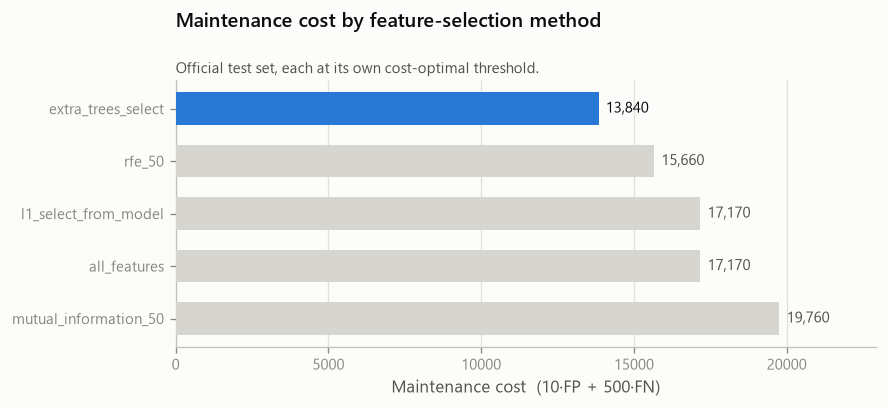

In [3]:
from scania_aps.plotting import emphasis_bars

label_column = "selector" if "selector" in selection.columns else selection.columns[0]

fig, ax = emphasis_bars(
    [str(v) for v in selection[label_column]],
    [float(v) for v in selection["total_cost"].to_numpy()],
    title="Maintenance cost by feature-selection method",
    subtitle="Official test set, each at its own cost-optimal threshold.",
    xlabel="Maintenance cost  (10·FP + 500·FN)",
)

## Which features, and do the methods agree?

Mutual information scores each feature against the target independently. Permutation
importance measures what a *fitted* model actually loses when a feature is shuffled. The
two answer different questions: the first is marginal, the second is conditional on
everything else in the model.

A feature can score highly on mutual information and near zero on permutation importance
simply because a correlated neighbour is already carrying the signal.

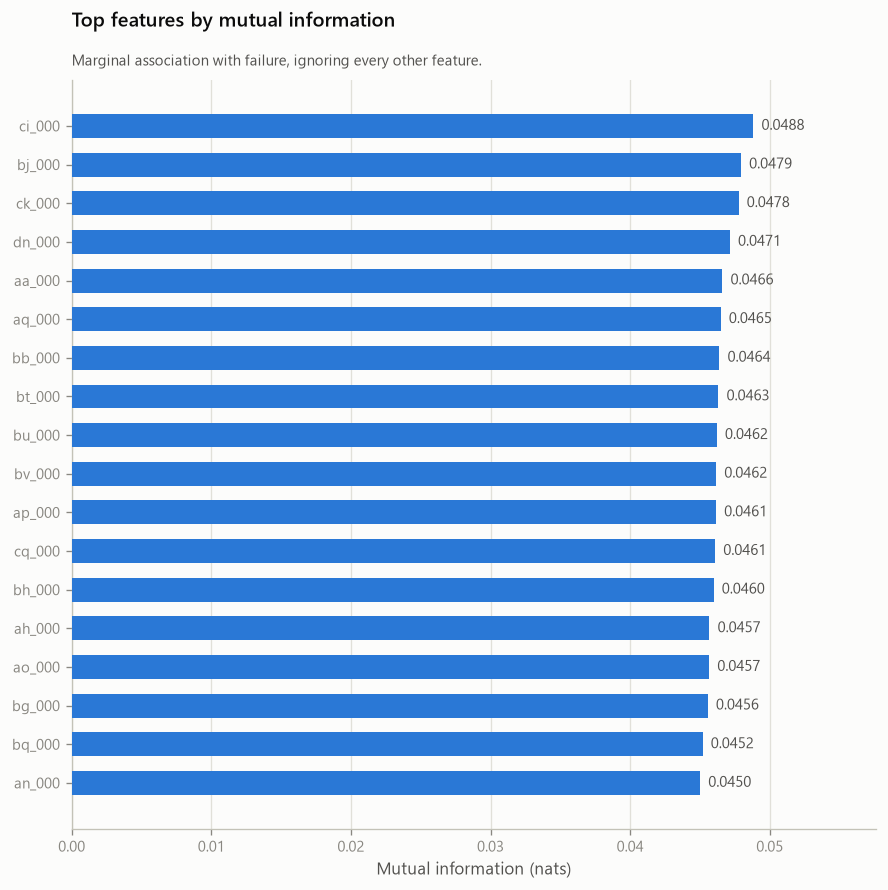

In [4]:
from scania_aps.feature_selection import mutual_information_ranking
from scania_aps.plotting import magnitude_bars

mi = mutual_information_ranking(train.X.fillna(train.X.median()), train.y)
top_mi = mi[:18]

fig, ax = magnitude_bars(
    [f.feature for f in top_mi],
    [f.score for f in top_mi],
    title="Top features by mutual information",
    subtitle="Marginal association with failure, ignoring every other feature.",
    xlabel="Mutual information (nats)",
    value_format="{:.4f}",
)

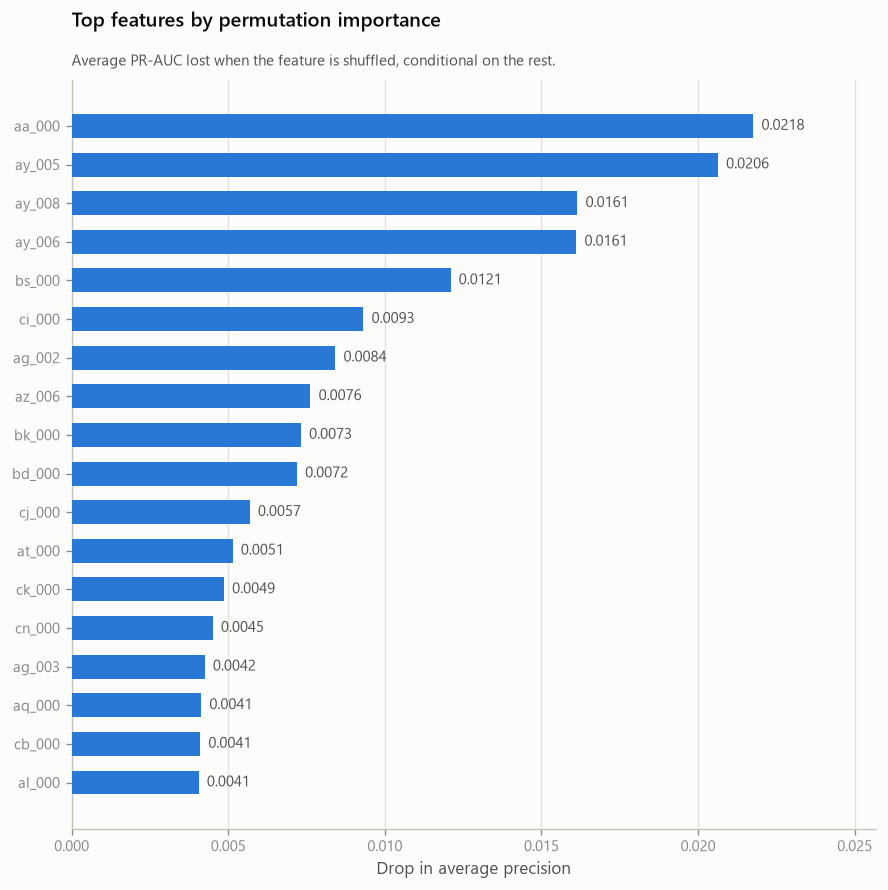

In [5]:
from scania_aps.feature_selection import permutation_ranking
from scania_aps.model_search import candidates_for_family
from scania_aps.models.factory import build_candidate
from scania_aps.split import development_split

split = development_split(train.X, train.y)
model = build_candidate(candidates_for_family("xgboost", profile="quick")[0])
model.fit(split.X_fit, split.y_fit)

# Bounded sample: permutation importance refits nothing but scores repeatedly.
sample = split.X_tune.sample(n=min(4000, len(split.X_tune)), random_state=42)
perm = permutation_ranking(model, sample, split.y_tune.loc[sample.index], n_repeats=5)
top_perm = perm[:18]

fig, ax = magnitude_bars(
    [f.feature for f in top_perm],
    [f.score for f in top_perm],
    title="Top features by permutation importance",
    subtitle="Average PR-AUC lost when the feature is shuffled, conditional on the rest.",
    xlabel="Drop in average precision",
    value_format="{:.4f}",
)

In [6]:
mi_rank = {f.feature: i for i, f in enumerate(mi)}
perm_rank = {f.feature: i for i, f in enumerate(perm)}

shared = sorted(set(mi_rank) & set(perm_rank), key=lambda f: perm_rank[f])
agreement = pd.DataFrame(
    {
        "feature": shared[:20],
        "permutation_rank": [perm_rank[f] + 1 for f in shared[:20]],
        "mutual_info_rank": [mi_rank[f] + 1 for f in shared[:20]],
    }
)
agreement["rank_gap"] = (agreement["permutation_rank"] - agreement["mutual_info_rank"]).abs()
agreement

,feature,permutation_rank,mutual_info_rank,rank_gap
0,aa_000,1,5,4
1,ay_005,2,118,116
2,ay_008,3,61,58
3,ay_006,4,109,105
4,bs_000,5,116,111
5,ci_000,6,1,5
6,ag_002,7,66,59
7,az_006,8,126,118
8,bk_000,9,78,69
9,bd_000,10,69,59


### Reading the result

Large values in `rank_gap` are the interesting rows. A feature the model leans on heavily
but which scores poorly on marginal association is doing work *in combination* with
others — the kind of interaction a univariate filter cannot see, and a reason to prefer
embedded or wrapper methods over `SelectKBest` on this data.

Compare the cost column in the first table against the full feature set. If selection
does not reduce cost, the honest conclusion is that the redundancy is not hurting, and
the argument for selection here is interpretability and runtime rather than accuracy.

**Next:** [12 — ablation study](12_ablation_study.ipynb), which asks which components
were load-bearing all along.